In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    auc
)

import pickle

In [2]:
# Load features and labels
X = np.load("/kaggle/input/notebooks/navishaaagarwaal/05-proposed-model/X_features.npy")
y = np.load("/kaggle/input/notebooks/navishaaagarwaal/05-proposed-model/y_labels.npy")

# Load trained model
with open("/kaggle/input/notebooks/navishaaagarwaal/05-proposed-model/xgb_model.pkl", "rb") as f:
    model = pickle.load(f)

# Generate predictions again
y_prob_mvsa = model.predict_proba(X)[:,1]
y_pred_mvsa = (y_prob_mvsa > 0.5).astype(int)

print("MVSA samples:", len(y))

MVSA samples: 11902


In [3]:
y_pred_hateful = np.load("/kaggle/input/notebooks/navishaaagarwaal/08-cross-dataset-valuation/hateful_y_pred.npy")
y_prob_hateful = np.load("/kaggle/input/notebooks/navishaaagarwaal/08-cross-dataset-valuation/hateful_y_prob.npy")
y_test_hateful = np.load("/kaggle/input/notebooks/navishaaagarwaal/08-cross-dataset-valuation/hateful_y_test.npy")

print("Hateful meme samples:", len(y_test_hateful))

Hateful meme samples: 1700


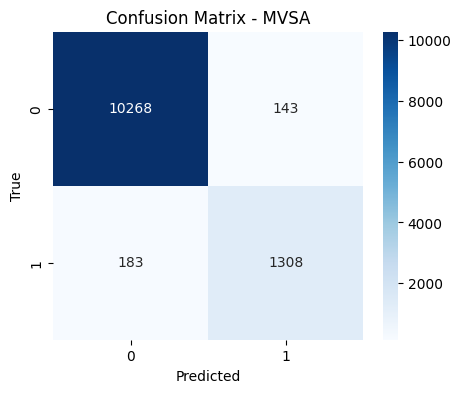

In [4]:
cm_mvsa = confusion_matrix(y, y_pred_mvsa)

plt.figure(figsize=(5,4))
sns.heatmap(cm_mvsa, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix - MVSA")
plt.xlabel("Predicted")
plt.ylabel("True")

plt.show()

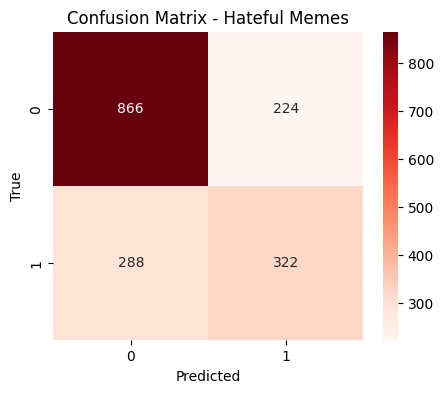

In [5]:
cm_hateful = confusion_matrix(y_test_hateful, y_pred_hateful)

plt.figure(figsize=(5,4))
sns.heatmap(cm_hateful, annot=True, fmt="d", cmap="Reds")

plt.title("Confusion Matrix - Hateful Memes")
plt.xlabel("Predicted")
plt.ylabel("True")

plt.show()

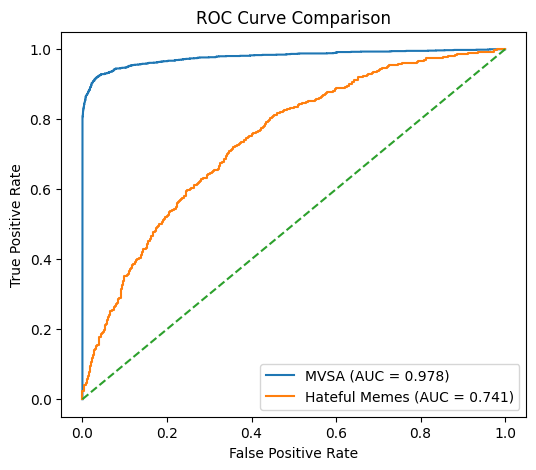

In [6]:
from sklearn.metrics import roc_auc_score

# MVSA
fpr_mvsa, tpr_mvsa, _ = roc_curve(y, y_prob_mvsa)
auc_mvsa = auc(fpr_mvsa, tpr_mvsa)

# Hateful Memes
fpr_hm, tpr_hm, _ = roc_curve(y_test_hateful, y_prob_hateful)
auc_hm = auc(fpr_hm, tpr_hm)

plt.figure(figsize=(6,5))

plt.plot(fpr_mvsa, tpr_mvsa, label=f"MVSA (AUC = {auc_mvsa:.3f})")
plt.plot(fpr_hm, tpr_hm, label=f"Hateful Memes (AUC = {auc_hm:.3f})")

plt.plot([0,1],[0,1],"--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")
plt.legend()

plt.show()

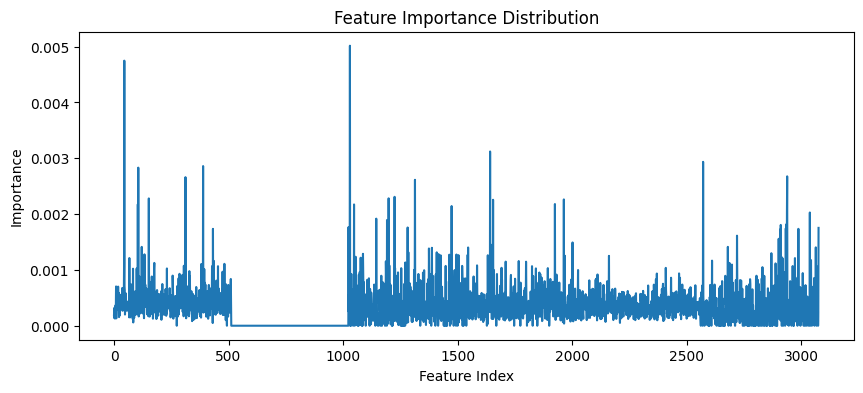

In [7]:
importances = model.feature_importances_

plt.figure(figsize=(10,4))
plt.plot(importances)

plt.title("Feature Importance Distribution")
plt.xlabel("Feature Index")
plt.ylabel("Importance")

plt.show()

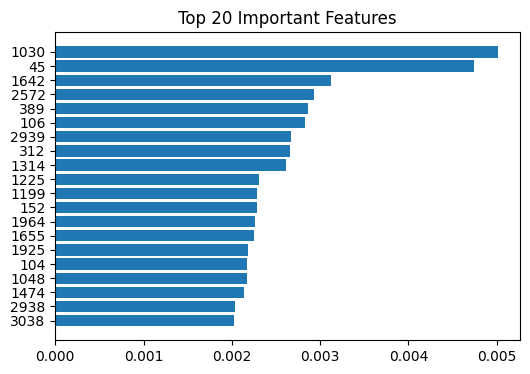

In [8]:
top_idx = np.argsort(importances)[-20:]

plt.figure(figsize=(6,4))
plt.barh(range(20), importances[top_idx])
plt.yticks(range(20), top_idx)

plt.title("Top 20 Important Features")

plt.show()

In [9]:
results = pd.DataFrame({

"Dataset":[
"MVSA",
"Hateful Memes"
],

"Samples":[
len(y),
len(y_test_hateful)
],

"ROC-AUC":[
auc_mvsa,
auc_hm
]

})

results

,Dataset,Samples,ROC-AUC
0,MVSA,11902,0.978341
1,Hateful Memes,1700,0.741065


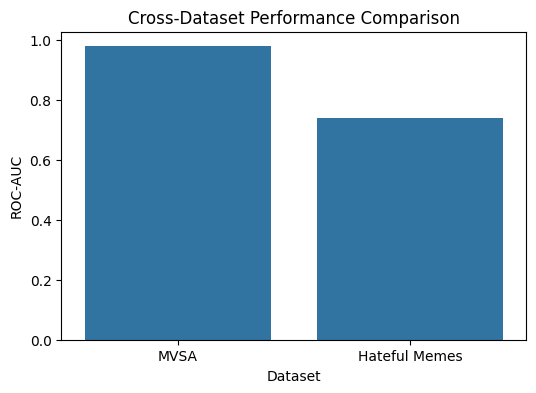

In [10]:
plt.figure(figsize=(6,4))

sns.barplot(
    x="Dataset",
    y="ROC-AUC",
    data=results
)

plt.title("Cross-Dataset Performance Comparison")

plt.show()